In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.ft_engineering import create_train_test, build_preprocessor
from src.modeling import build_model
from src.evaluation import summarize_classification

In [3]:
df = pd.read_csv("../data/dataset_limpio.csv")
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,True
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,True
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,False
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,True
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,True


In [4]:
#Definir variable objetivo

target_column = "Pago_atiempo"

df[target_column].value_counts()

Pago_atiempo
True     10113
False      500
Name: count, dtype: int64

In [ ]:
df[target_column].value_counts(normalize=True)

#Esto te muestra si la variable objetivo está balanceada o no, y vemos que no 

Pago_atiempo
True     0.952888
False    0.047112
Name: proportion, dtype: float64

In [6]:
#Separamos en x e y
X = df.drop(columns=[target_column])
y = df[target_column]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (10613, 22)
Shape de y: (10613,)


In [7]:
#Detectar columnas numéricas y categóricas

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Variables categóricas:
['fecha_prestamo', 'tipo_laboral', 'tendencia_ingresos']


In [8]:
#Convertir fecha a datetime

df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"])

df["anio_prestamo"] = df["fecha_prestamo"].dt.year
df["mes_prestamo"] = df["fecha_prestamo"].dt.month
df["dia_semana_prestamo"] = df["fecha_prestamo"].dt.dayofweek

df = df.drop(columns=["fecha_prestamo"])

df.head()

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo,anio_prestamo,mes_prestamo,dia_semana_prestamo
0,7,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,...,0.0,5,0,0,908526.0,Estable,True,2024,12,5
1,4,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,...,0.0,0,0,2,939017.0,Creciente,True,2025,4,1
2,9,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,...,0.0,3,0,0,NaN,NaN,False,2026,1,3
3,4,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,...,0.0,3,0,0,1536193.0,Creciente,True,2025,8,0
4,9,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,...,0.0,3,0,1,933473.0,Creciente,True,2025,4,5


In [9]:
X = df.drop(columns=[target_column])
y = df[target_column]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Variables categóricas:
['tipo_laboral', 'tendencia_ingresos']


In [10]:
#Importamos librerias de pipeline

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

In [11]:
#Crear train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8490, 24)
X_test: (2123, 24)


In [12]:
#Crear pipeline numérico

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [13]:
#Crear pipeline categórico
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [14]:
#Crear preprocessor completo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [15]:
#Importar modelos y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [16]:
#Crear función build_model
def build_model(model_name, preprocessor):
    models = {
        "logistic_regression": LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ),
        "decision_tree": DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=6
        ),
        "random_forest": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_estimators=200,
            max_depth=8
        )
    }

    if model_name not in models:
        raise ValueError(f"Modelo no reconocido: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", models[model_name])
    ])

    return pipeline

In [17]:
#Crear función summarize_classification
def summarize_classification(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = None

    summary = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }

    return summary

In [18]:
#Entrenar modelos

model_names = [
    "logistic_regression",
    "decision_tree",
    "random_forest"
]

results = []
trained_models = {}

for model_name in model_names:
    model = build_model(model_name, preprocessor)
    model.fit(X_train, y_train)

    summary = summarize_classification(
        model=model,
        X_test=X_test,
        y_test=y_test,
        model_name=model_name
    )

    results.append(summary)
    trained_models[model_name] = model

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


In [19]:
#Ver tabla resumen

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.997645,1.0,0.997528,0.998763,0.999951
1,decision_tree,1.000000,1.0,1.000000,1.000000,1.000000
2,random_forest,1.000000,1.0,1.000000,1.000000,1.000000


In [20]:
results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
1,decision_tree,1.000000,1.0,1.000000,1.000000,1.000000
2,random_forest,1.000000,1.0,1.000000,1.000000,1.000000
0,logistic_regression,0.997645,1.0,0.997528,0.998763,0.999951


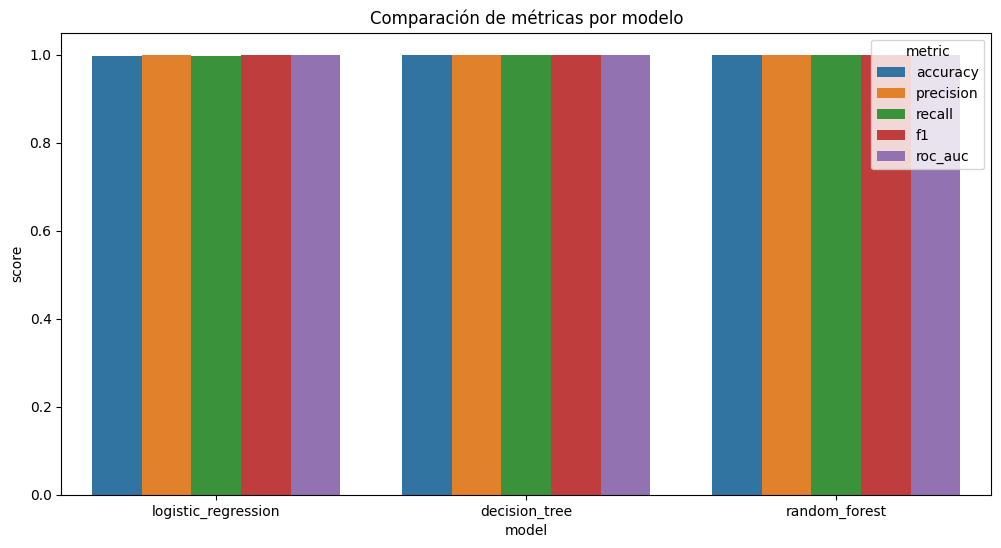

In [21]:
#Gráfico comparativo de métricas

results_melted = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Comparación de métricas por modelo")
plt.ylim(0, 1.05)

plt.show()

In [22]:
#Elegimos el mejor modelo

best_model_name = results_df.sort_values(
    by="f1",
    ascending=False
).iloc[0]["model"]

best_model = trained_models[best_model_name]

print("Mejor modelo:", best_model_name)

Mejor modelo: decision_tree


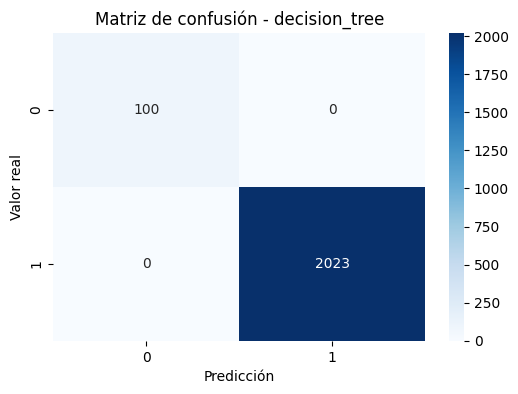

In [23]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       100
        True       1.00      1.00      1.00      2023

    accuracy                           1.00      2123
   macro avg       1.00      1.00      1.00      2123
weighted avg       1.00      1.00      1.00      2123



En este avance se construyó un pipeline modular de Machine Learning utilizando Scikit-Learn. Primero se aplicó ingeniería de características sobre el dataset limpio, incluyendo transformaciones sobre variables de fecha y separación de variables numéricas y categóricas. Luego se construyó un pipeline de preprocesamiento con imputación, escalado y codificación de variables. Posteriormente, se entrenaron distintos modelos supervisados y se compararon mediante métricas de clasificación como Accuracy, Precision, Recall, F1-score y ROC-AUC.

Los modelos basados en árboles obtuvieron métricas prácticamente perfectas, lo que podría indicar la presencia de data leakage en algunas variables relacionadas con saldos o mora. Esto representa una observación importante para futuras iteraciones del proyecto, donde convendría validar qué variables estarían realmente disponibles al momento de otorgar el crédito.

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")